In [ ]:
# ============================================================
# Setup — reproduces all preprocessing decisions from prior session
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Load ---
df = pd.read_csv("HR_data_2.csv", index_col=0)

# --- Define column groups ---
metadata_cols = ['Round', 'Phase', 'Individual', 'Puzzler', 'original_ID', 
                 'raw_data_path', 'Team_ID', 'Cohort']
emotion_cols  = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 
                 'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']
biosignal_cols = [c for c in df.columns if c not in metadata_cols + emotion_cols]

# --- Drop the 1 row with missing EDA timing features (Decision B) ---
biosignal_view = df.dropna(subset=biosignal_cols).copy().reset_index(drop=True)

# --- Convenience arrays ---
X                 = biosignal_view[biosignal_cols].values
phase_labels      = biosignal_view['Phase'].values
individual_labels = biosignal_view['Individual'].values

print(f"Biosignal view: {biosignal_view.shape[0]} rows × {len(biosignal_cols)} features")
print(f"Phase counts: {dict(pd.Series(phase_labels).value_counts())}")
print(f"Individuals:  {len(np.unique(individual_labels))}")

Biosignal view: 311 rows × 51 features
Phase counts: {'phase3': 104, 'phase2': 104, 'phase1': 103}
Individuals:  26


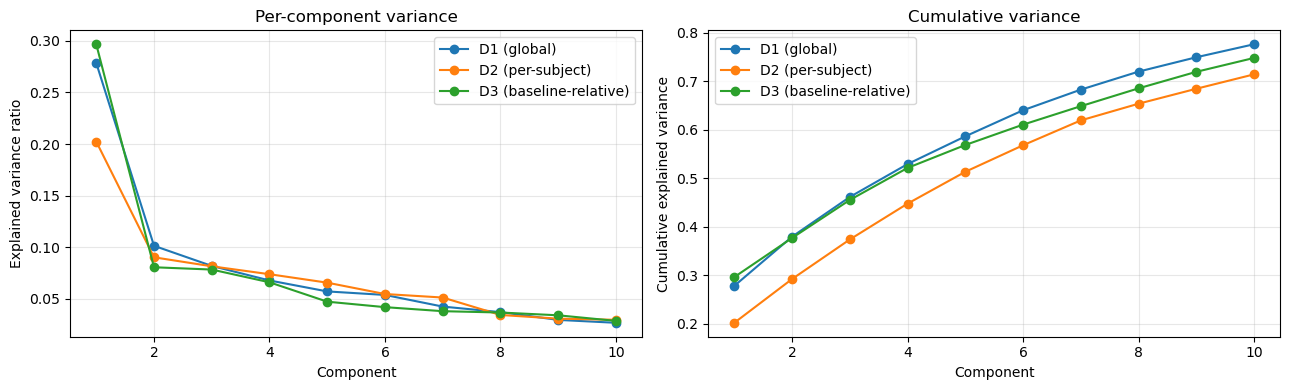

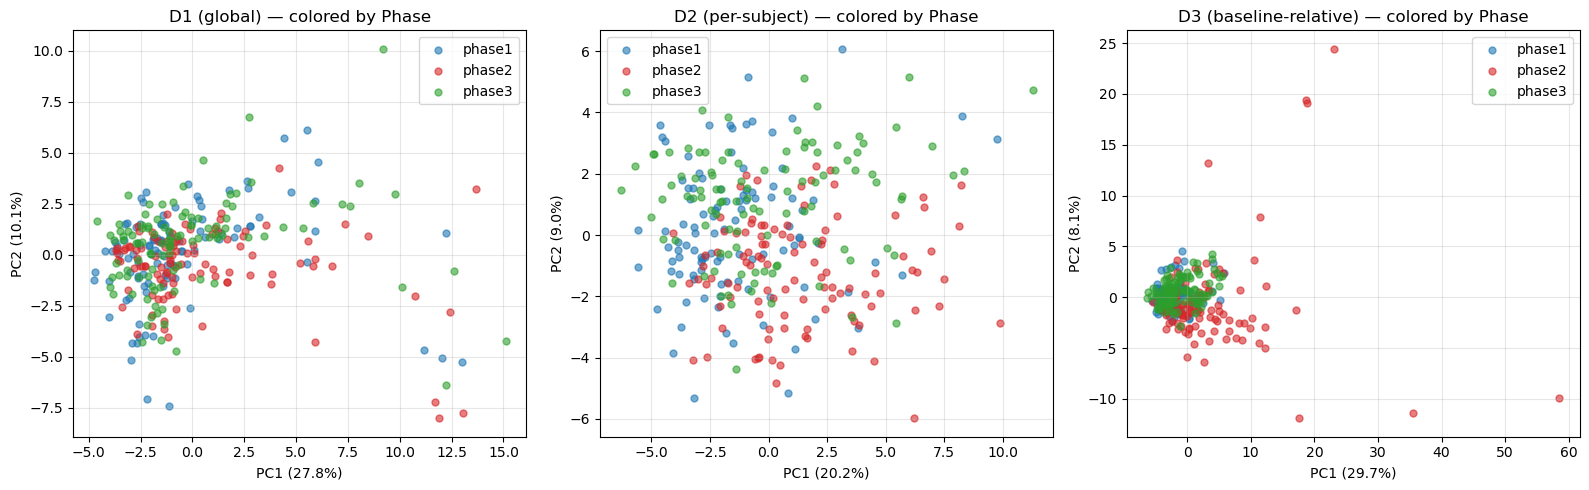

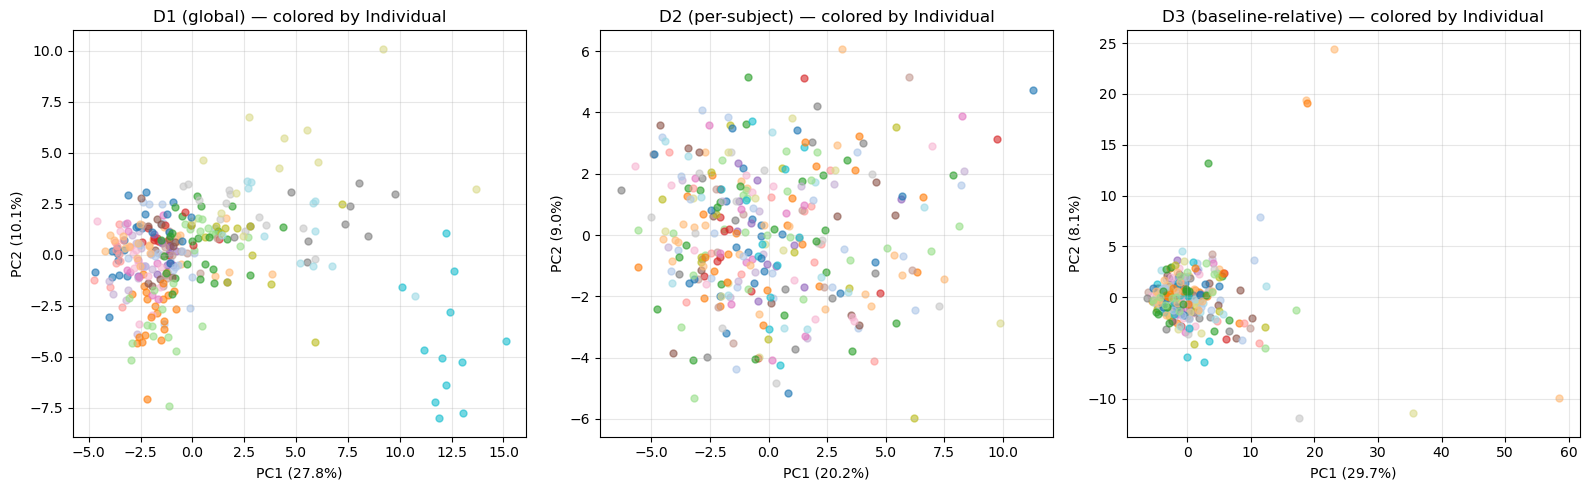


=== Top 8 |loadings| on PC1 ===
                    D1 (global)  D2 (per-subject)  D3 (baseline-relative)
EDA_TD_P_Median           0.205             0.241                   0.605
EDA_TD_P_AUC              0.225             0.285                   0.382
EDA_TD_P_Mean             0.224             0.286                   0.348
EDA_TD_P_std              0.246             0.279                   0.177
EDA_TD_P_Max              0.249             0.268                   0.144
EDA_TD_P_Slope_min        0.234             0.251                   0.125
EDA_TD_P_Slope            0.176             0.075                   0.249
EDA_TD_T_Slope_max        0.239             0.245                   0.173

=== Top 8 |loadings| on PC2 ===
                    D1 (global)  D2 (per-subject)  D3 (baseline-relative)
EDA_TD_P_Min              0.017             0.051                   0.599
EDA_TD_T_Slope_min        0.022             0.107                   0.367
HR_TD_Max                 0.321             0.

In [3]:
# We already have:
#   biosignal_view (DataFrame with 311 rows + metadata)
#   X (the 311 x 51 array of biosignal features)
#   biosignal_cols (list of feature names)
#   phase_labels, individual_labels (from earlier)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# Build the three standardized feature matrices: D1, D2, D3
# ============================================================

# D1 — Global standardization
X_d1 = StandardScaler().fit_transform(X)

# D2 — Per-subject standardization
X_d2 = np.zeros_like(X)
for ind in np.unique(individual_labels):
    mask = individual_labels == ind
    X_d2[mask] = StandardScaler().fit_transform(X[mask])

# D3 — Baseline-relative (subtract per-subject resting mean, divide by per-subject resting std)
X_d3 = np.zeros_like(X)
for ind in np.unique(individual_labels):
    mask = individual_labels == ind
    rest_mask = mask & ((biosignal_view['Phase'] == 'phase1') | 
                        (biosignal_view['Phase'] == 'phase3')).values
    rest_data = X[rest_mask]
    rest_mean = rest_data.mean(axis=0)
    rest_std = rest_data.std(axis=0)
    rest_std_safe = np.where(rest_std > 0, rest_std, 1)
    X_d3[mask] = (X[mask] - rest_mean) / rest_std_safe

pipelines = {'D1 (global)': X_d1, 'D2 (per-subject)': X_d2, 'D3 (baseline-relative)': X_d3}

# ============================================================
# Run PCA on each
# ============================================================
pca_results = {}
for name, X_pipe in pipelines.items():
    pca = PCA()
    X_pca = pca.fit_transform(X_pipe)
    pca_results[name] = {
        'X_pca': X_pca,
        'explained_var': pca.explained_variance_ratio_,
        'components': pca.components_,
    }
    
# ============================================================
# Plot 1 — Explained variance curves
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name, r in pca_results.items():
    ax[0].plot(range(1, 11), r['explained_var'][:10], 'o-', label=name)
    ax[1].plot(range(1, 11), np.cumsum(r['explained_var'][:10]), 'o-', label=name)
ax[0].set_xlabel('Component'); ax[0].set_ylabel('Explained variance ratio')
ax[0].set_title('Per-component variance'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_xlabel('Component'); ax[1].set_ylabel('Cumulative explained variance')
ax[1].set_title('Cumulative variance'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2 — PC1/PC2 scatter colored by PHASE (3 panels)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
phase_colors = {'phase1': 'tab:blue', 'phase2': 'tab:red', 'phase3': 'tab:green'}
for ax, (name, r) in zip(axes, pca_results.items()):
    for ph, color in phase_colors.items():
        mask = phase_labels == ph
        ax.scatter(r['X_pca'][mask, 0], r['X_pca'][mask, 1],
                   c=color, label=ph, alpha=0.6, s=25)
    ax.set_xlabel(f"PC1 ({r['explained_var'][0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({r['explained_var'][1]*100:.1f}%)")
    ax.set_title(f'{name} — colored by Phase')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3 — PC1/PC2 scatter colored by INDIVIDUAL (3 panels)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmap = plt.cm.tab20
for ax, (name, r) in zip(axes, pca_results.items()):
    for i, ind in enumerate(np.unique(individual_labels)):
        mask = individual_labels == ind
        ax.scatter(r['X_pca'][mask, 0], r['X_pca'][mask, 1],
                   c=[cmap(i % 20)], label=f'Ind {ind}' if i < 10 else None,
                   alpha=0.6, s=25)
    ax.set_xlabel(f"PC1 ({r['explained_var'][0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({r['explained_var'][1]*100:.1f}%)")
    ax.set_title(f'{name} — colored by Individual')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loadings for PC1 and PC2 across pipelines
# ============================================================
for pc_idx in [0, 1]:
    print(f"\n=== Top 8 |loadings| on PC{pc_idx+1} ===")
    loading_df = pd.DataFrame({
        name: pd.Series(np.abs(r['components'][pc_idx]), index=biosignal_cols)
        for name, r in pca_results.items()
    })
    top_features = loading_df.max(axis=1).sort_values(ascending=False).head(8).index
    print(loading_df.loc[top_features].round(3))

## PCA across three standardization pipelines

Compared global (D1), per-subject (D2), and baseline-relative (D3) standardization.

**Variance structure:**
- D1 PC1 explains 28% of variance, dominated by inter-subject EDA reactivity 
  differences (Individual 19 visibly clusters at the high-PC1 extreme).
- D2 flattens the curve (PC1 explains 20%) because removing per-subject means 
  eliminates the largest single source of variance.
- D3 PC1 explains 30%, but represents something fundamentally different: 
  per-subject deviation from resting baseline.

**Phase separability:**
- D1: phases are completely intermixed in the PC1/PC2 plane.
- D2: subtle but visible phase structure emerges; phase 2 (puzzle) tends 
  toward negative PC2.
- D3: clearer asymmetry; rest phases (1, 3) cluster near origin while many 
  puzzle-phase (2) recordings deviate substantially along PC1, indicating 
  that puzzle phases produce systematic deviations from each subject's resting baseline.

**Physiological interpretation of components:**
- D1 and D2 yield similar component meanings: PC1 captures EDA activity 
  (phasic and tonic), PC2 captures heart-rate level.
- D3 components capture deviation from rest: PC1 is dominated by phasic 
  EDA median (loading 0.61), PC2 by phasic EDA minimum and tonic EDA slope.

**Headline finding:** Inter-subject variation dominates the unsupervised structure 
of this dataset. Phase-related structure exists but is small relative to between-
subject differences and is only accessible after explicitly removing individual 
baselines. Phasic EDA is the primary biosignal axis on which experimental phase 
manifests.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score
import pandas as pd
import numpy as np

# ============================================================
# 1. Variance partitioning: between-subject vs within-subject
# ============================================================
# For each feature, decompose total variance into two parts:
#   - between-subject: variance of subject means (weighted by group size)
#   - within-subject:  mean of variances within each subject
#
# Total variance = between + within (this is the ANOVA decomposition).
# Then sum over features to get a single number.

def variance_partition(X_input, group_labels):
    """Return (between-subject fraction, within-subject fraction) of total variance."""
    df_local = pd.DataFrame(X_input)
    df_local['group'] = group_labels
    
    # Per-feature totals
    grand_mean = df_local.drop(columns='group').mean(axis=0)
    total_ss = ((df_local.drop(columns='group') - grand_mean) ** 2).sum().sum()
    
    # Between-group sum of squares
    group_means = df_local.groupby('group').mean()
    group_sizes = df_local.groupby('group').size()
    between_ss = ((group_means - grand_mean) ** 2).mul(group_sizes, axis=0).sum().sum()
    
    # Within-group sum of squares
    within_ss = total_ss - between_ss
    
    return between_ss / total_ss, within_ss / total_ss

# Apply to each pipeline
print("=== Variance partition (subject as grouping) ===")
print(f"{'Pipeline':<25}{'Between-subject':>18}{'Within-subject':>18}")
for name, X_pipe in pipelines.items():
    between, within = variance_partition(X_pipe, individual_labels)
    print(f"{name:<25}{between*100:>17.1f}%{within*100:>17.1f}%")

# Also do it grouping by phase (how much variance is between-phase?)
print("\n=== Variance partition (phase as grouping) ===")
print(f"{'Pipeline':<25}{'Between-phase':>18}{'Within-phase':>18}")
for name, X_pipe in pipelines.items():
    between, within = variance_partition(X_pipe, phase_labels)
    print(f"{name:<25}{between*100:>17.1f}%{within*100:>17.1f}%")

# ============================================================
# 2. Phase effect on PC1/PC2 — eta-squared per component
# ============================================================
# eta-squared = (between-phase SS) / (total SS) for each PC
# Tells us: what fraction of the variance of each PC is explained by phase?

print("\n=== Phase effect on PCs (eta-squared, %) ===")
print(f"{'Pipeline':<25}{'PC1':>10}{'PC2':>10}{'PC3':>10}")
for name, r in pca_results.items():
    row = f"{name:<25}"
    for pc_idx in [0, 1, 2]:
        scores = r['X_pca'][:, pc_idx]
        # eta-squared
        grand_mean = scores.mean()
        total_ss = ((scores - grand_mean) ** 2).sum()
        phase_means = pd.Series(scores).groupby(phase_labels).mean()
        phase_sizes = pd.Series(scores).groupby(phase_labels).size()
        between_ss = ((phase_means - grand_mean) ** 2 * phase_sizes).sum()
        eta_sq = between_ss / total_ss
        row += f"{eta_sq*100:>9.2f}%"
    print(row)

# Also: mean PC1 score per phase, per pipeline
print("\n=== Mean PC1 score per phase ===")
print(f"{'Pipeline':<25}{'phase1':>10}{'phase2':>10}{'phase3':>10}")
for name, r in pca_results.items():
    row = f"{name:<25}"
    for ph in ['phase1', 'phase2', 'phase3']:
        mask = phase_labels == ph
        row += f"{r['X_pca'][mask, 0].mean():>10.3f}"
    print(row)

# ============================================================
# 3. Predictability of phase from first few PCs (subject-level CV)
# ============================================================
# Use Leave-One-Subject-Out CV to honestly estimate generalization.
# Logistic regression on first 5 PCs predicting phase.

print("\n=== Phase prediction balanced accuracy (LOSO-CV) ===")
print(f"{'Pipeline':<25}{'mean':>10}{'std':>10}  (chance = 33.3%)")

logo = LeaveOneGroupOut()
n_pcs = 5

for name, r in pca_results.items():
    X_feat = r['X_pca'][:, :n_pcs]
    accs = []
    for train_idx, test_idx in logo.split(X_feat, phase_labels, individual_labels):
        clf = LogisticRegression(max_iter=2000, multi_class='multinomial')
        clf.fit(X_feat[train_idx], phase_labels[train_idx])
        preds = clf.predict(X_feat[test_idx])
        accs.append(balanced_accuracy_score(phase_labels[test_idx], preds))
    accs = np.array(accs)
    print(f"{name:<25}{accs.mean()*100:>9.1f}%{accs.std()*100:>9.1f}%")

=== Variance partition (subject as grouping) ===
Pipeline                    Between-subject    Within-subject
D1 (global)                           45.1%             54.9%
D2 (per-subject)                       0.0%            100.0%
D3 (baseline-relative)                 9.5%             90.5%

=== Variance partition (phase as grouping) ===
Pipeline                      Between-phase      Within-phase
D1 (global)                            2.4%             97.6%
D2 (per-subject)                       5.7%             94.3%
D3 (baseline-relative)                 7.4%             92.6%

=== Phase effect on PCs (eta-squared, %) ===
Pipeline                        PC1       PC2       PC3
D1 (global)                   1.16%     3.61%     0.42%
D2 (per-subject)             11.78%    19.94%     1.86%
D3 (baseline-relative)       18.31%     2.77%     7.82%

=== Mean PC1 score per phase ===
Pipeline                     phase1    phase2    phase3
D1 (global)                  -0.475     0.518  

## Quantification of PCA findings

**Variance partitioning of biosignal features (Decision sub-question 1):**
Under global standardization (D1), 45.1% of total variance in the 51-dimensional 
biosignal feature space was between-subject, compared to only 2.4% between-phase — 
an 18-fold dominance of inter-individual differences over experimental condition. 
Per-subject standardization (D2) removes between-subject variance by construction; 
baseline-relative standardization (D3) retains 9.5% (reflecting per-subject scale 
differences in physiological reactivity).

**Phase information in PCA components (Decision sub-question 2):**
The fraction of each principal component's variance attributable to phase 
(eta-squared) increased markedly with per-subject preprocessing:

| Pipeline | PC1 η² | PC2 η² |
|----------|-------:|-------:|
| D1 (global)         |  1.2% |  3.6% |
| D2 (per-subject)    | 11.8% | 19.9% |
| D3 (baseline-rel.)  | 18.3% |  2.8% |

Mean PC1 scores by phase confirmed the pattern: under D3, rest phases averaged 
–2.3 (pre-) and –1.2 (post-), while puzzle averaged +3.5, with the asymmetry 
between pre- and post-rest suggesting incomplete physiological recovery.

**Generalization across subjects (Leave-One-Subject-Out CV):**
Logistic regression on the first 5 PCs predicting phase, evaluated by LOSO-CV:

| Pipeline | Balanced accuracy |
|----------|-----------------:|
| D1 | 48.0% ± 12.2% |
| D2 | 57.4% ± 16.6% |
| D3 | 56.1% ± 16.6% |
| Chance | 33.3% |

All pipelines exceeded chance, with per-subject preprocessing yielding 
~9 percentage points of improvement. Large standard deviations reflect substantial 
inter-subject variability in how predictably the physiological signature of 
phase generalizes — some held-out individuals are predicted well, others 
near chance. This is consistent with known heterogeneity in autonomic responses 
to stress.

**Headline:** Phase-related structure in biosignal features is real, generalizes 
across subjects, and is roughly 5–10× more accessible after per-subject baseline 
correction. The signal is weak but not negligible: ~57% balanced accuracy on a 
3-class problem under the strictest validation scheme.